# Time Series Stock Price using Time Series Analysis

In [39]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
data = pd.read_csv(r"C:\Users\maorm\Desktop\BAJAJFINSV.csv")

# 1. Data Cleaning

In [41]:
data.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,Volume,Turnover,Trades,Deliverable Volume,%Deliverble
0,2008-05-26,BAJAJFINSV,EQ,2101.05,600.00,619.00,501.0,505.1,509.10,548.85,3145446,1.726368e+14,NaN,908264,0.2888
1,2008-05-27,BAJAJFINSV,EQ,509.10,505.00,610.95,491.1,564.0,554.65,572.15,4349144,2.488370e+14,NaN,677627,0.1558
2,2008-05-28,BAJAJFINSV,EQ,554.65,564.00,665.60,564.0,643.0,640.95,618.37,4588759,2.837530e+14,NaN,774895,0.1689
3,2008-05-29,BAJAJFINSV,EQ,640.95,656.65,703.00,608.0,634.5,632.40,659.60,4522302,2.982921e+14,NaN,1006161,0.2225
4,2008-05-30,BAJAJFINSV,EQ,632.40,642.40,668.00,588.3,647.0,644.00,636.41,3057669,1.945929e+14,NaN,462832,0.1514


In [42]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Prev Close,3201.0,2.755864e+03,2.869812e+03,9.075000e+01,5.279000e+02,1.098700e+03,5.121900e+03,1.117655e+04
Open,3201.0,2.760382e+03,2.874814e+03,8.815000e+01,5.286000e+02,1.095000e+03,5.120000e+03,1.100000e+04
High,3201.0,2.803614e+03,2.912885e+03,9.310000e+01,5.426000e+02,1.118000e+03,5.199800e+03,1.130000e+04
Low,3201.0,2.716731e+03,2.834037e+03,8.815000e+01,5.200000e+02,1.080250e+03,5.042800e+03,1.086870e+04
Last,3201.0,2.758782e+03,2.873793e+03,9.100000e+01,5.279500e+02,1.100000e+03,5.115000e+03,1.117545e+04
Close,3201.0,2.758657e+03,2.873523e+03,9.075000e+01,5.279000e+02,1.098700e+03,5.125100e+03,1.117655e+04
VWAP,3201.0,2.761157e+03,2.874034e+03,8.926000e+01,5.312700e+02,1.103560e+03,5.127510e+03,1.108178e+04
Volume,3201.0,2.315312e+05,4.402681e+05,4.570000e+02,3.981100e+04,9.995300e+04,2.315400e+05,6.271671e+06
Turnover,3201.0,9.533424e+13,2.176448e+14,1.376712e+10,2.751053e+12,1.090486e+13,8.755946e+13,3.394379e+15
Trades,2456.0,2.089281e+04,3.239630e+04,1.490000e+02,2.951750e+03,9.450000e+03,2.443975e+04,3.129590e+05


In [43]:
data.isnull().sum()

Date                    0
Symbol                  0
Series                  0
Prev Close              0
Open                    0
High                    0
Low                     0
Last                    0
Close                   0
VWAP                    0
Volume                  0
Turnover                0
Trades                745
Deliverable Volume      0
%Deliverble             0
dtype: int64

In [44]:
df = data.drop(columns = ['Trades'], axis = 1)

In [45]:
df.isnull().sum()

Date                  0
Symbol                0
Series                0
Prev Close            0
Open                  0
High                  0
Low                   0
Last                  0
Close                 0
VWAP                  0
Volume                0
Turnover              0
Deliverable Volume    0
%Deliverble           0
dtype: int64

# 2. Data Analysis

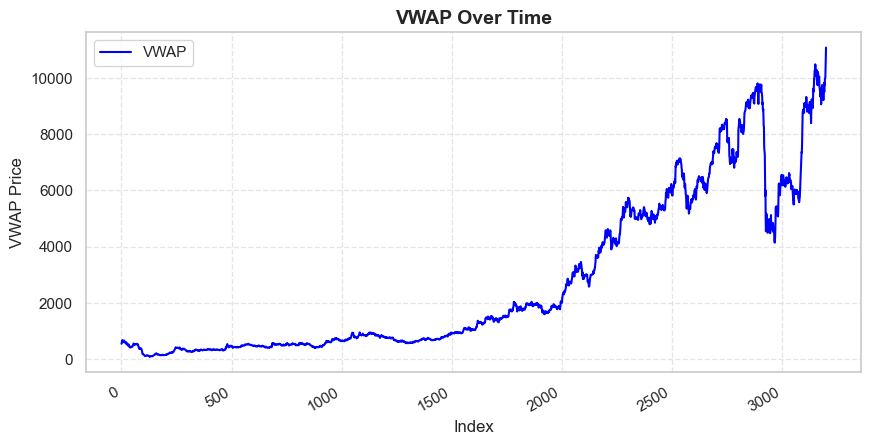

In [46]:
plt.figure(figsize=(10, 5))

# Plot Date on X and VWAP on Y
plt.plot(df['VWAP'], color='blue', linewidth=1.5, label='VWAP')

# Clean up the chart
plt.title('VWAP Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Index', fontsize=12)
plt.ylabel('VWAP Price', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Automatically format and rotate the date labels so they don't overlap
plt.gcf().autofmt_xdate() 

plt.legend()
plt.show()

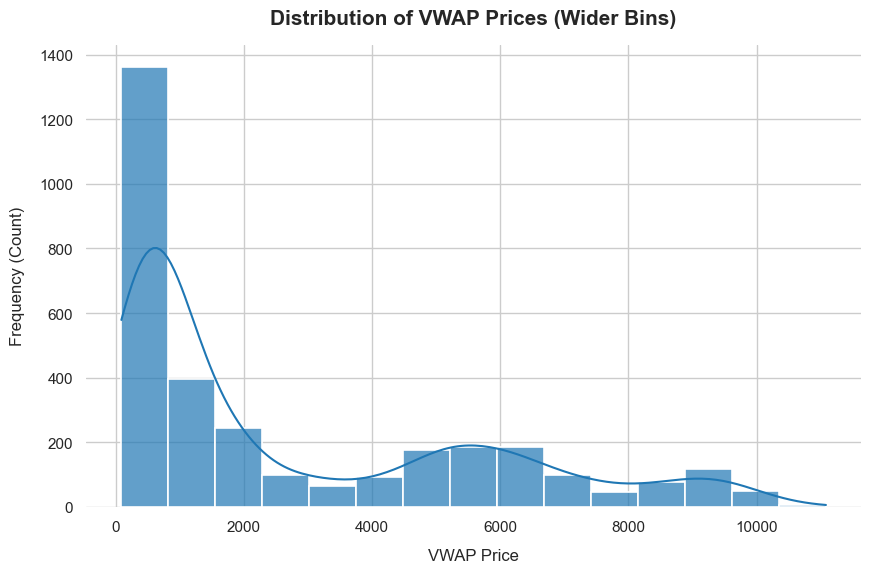

In [47]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Change bins to a smaller number (e.g., 15) to make the bars wider/bigger
sns.histplot(
    data=df, 
    x='VWAP', 
    kde=True, 
    color='#1f77b4',     
    bins=15,             # <-- Change this to 10, 15, or 20 for bigger bins!
    edgecolor='white',   
    linewidth=1.2,       
    alpha=0.7            
)

plt.title('Distribution of VWAP Prices (Wider Bins)', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('VWAP Price', fontsize=12, labelpad=10)
plt.ylabel('Frequency (Count)', fontsize=12, labelpad=10)
sns.despine(left=True, bottom=True)

plt.show()

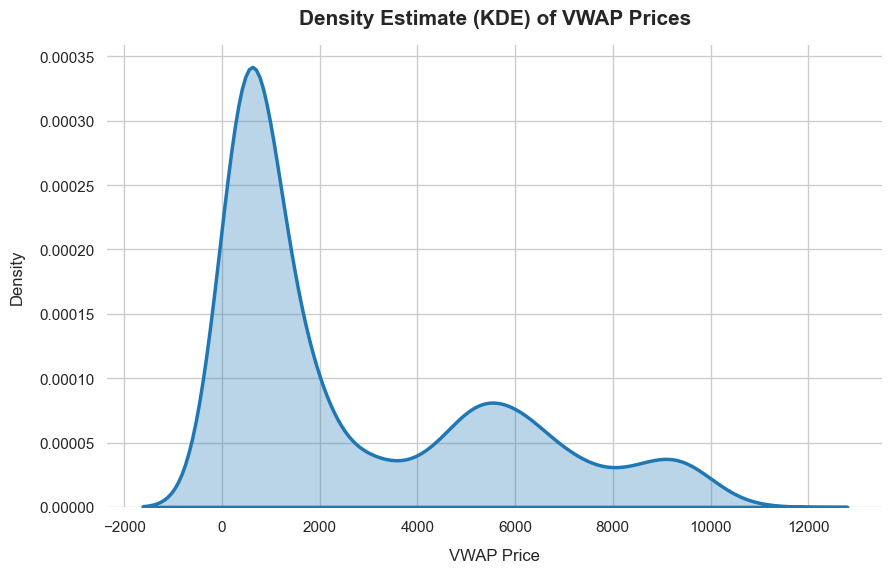

In [48]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Create the density plot
sns.kdeplot(
    data=df, 
    x='VWAP', 
    fill=True,           
    color='#1f77b4',     
    alpha=0.3,          
    linewidth=2.5        
)


plt.title('Density Estimate (KDE) of VWAP Prices', fontsize=15, fontweight='bold', pad=15)
plt.xlabel('VWAP Price', fontsize=12, labelpad=10)
plt.ylabel('Density', fontsize=12, labelpad=10)

sns.despine(left=True, bottom=True)
plt.show()

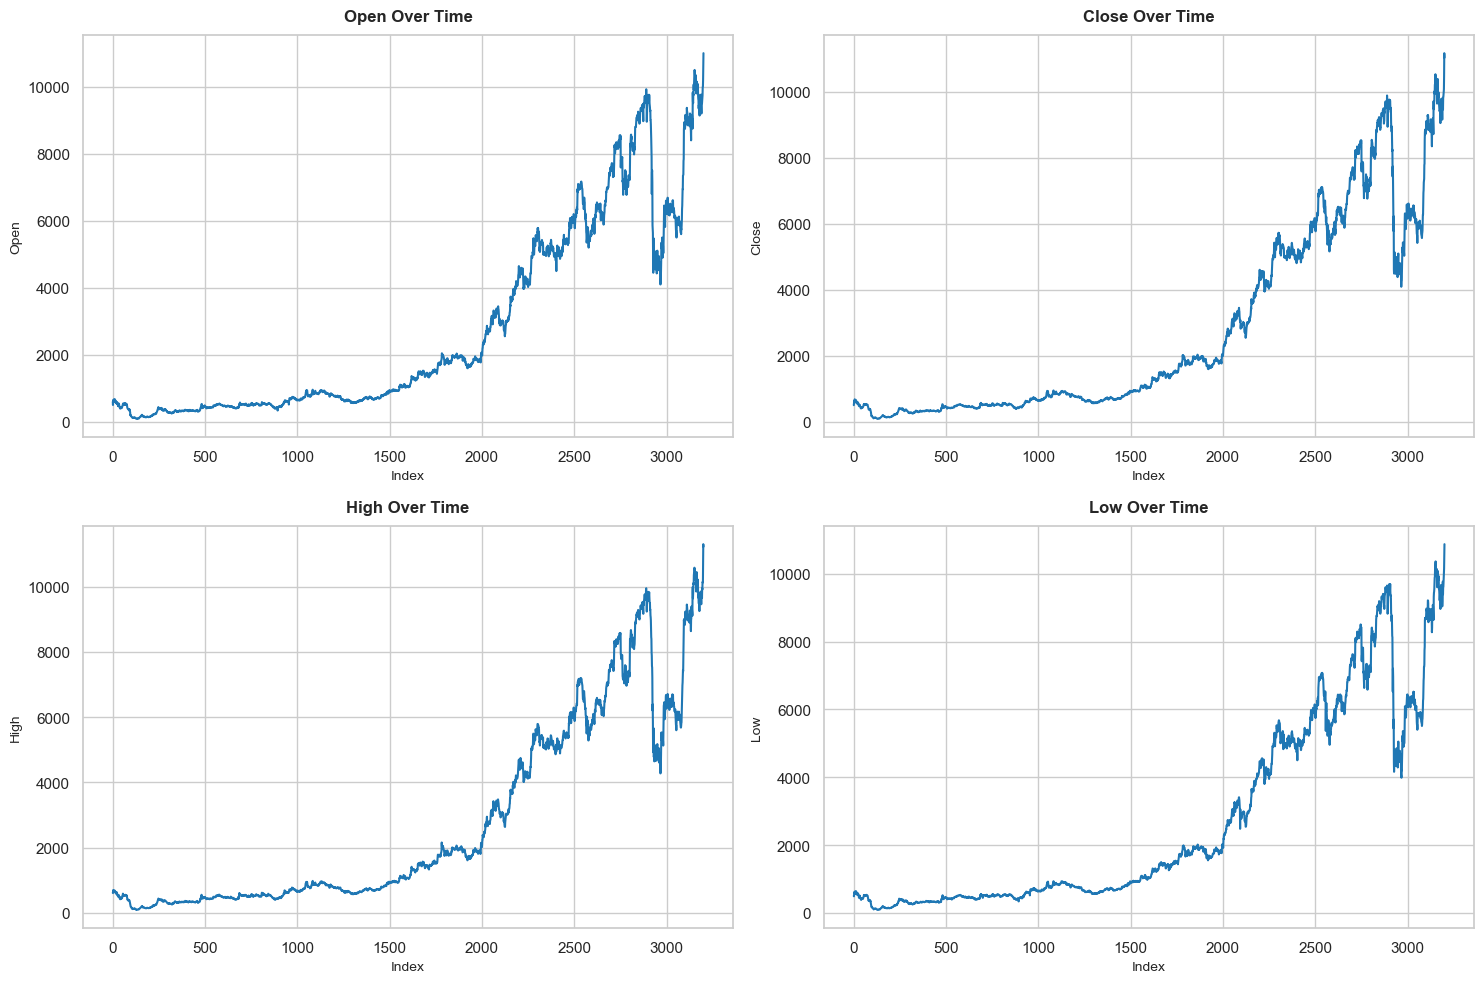

In [49]:
columns_to_plot = ['Open', 'Close', 'High', 'Low']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()
sns.set_theme(style="whitegrid")

for i, col in enumerate(columns_to_plot):
    ax = axes[i]
    
    # Explicitly set x to the DataFrame's index
    sns.lineplot(data=df, x=df.index, y=col, ax=ax, color='#1f77b4', linewidth=1.5)
    
    ax.set_title(f'{col} Over Time', fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel('Index', fontsize=10) # Updated label name
    ax.set_ylabel(col, fontsize=10)

plt.tight_layout()
plt.show()

# 3. Feature Engineering

In [50]:
# 1. Define base numerical columns for generating moving statistics
lag_features = ["High", "Low", "Volume", "Turnover"]

# 2. Compute rolling statistics (moving averages & standard deviations)
for col in lag_features:
    # 3-day and 7-day rolling means (moving averages)
    df[col + "_rolling_mean_3"] = df[col].rolling(window=3).mean()
    df[col + "_rolling_mean_7"] = df[col].rolling(window=7).mean()

    # 3-day and 7-day rolling standard deviations (moving volatility)
    df[col + "_rolling_std_3"] = df[col].rolling(window=3).std()
    df[col + "_rolling_std_7"] = df[col].rolling(window=7).std()

# 3. Drop initial rows containing NaN values created by rolling windows
df.dropna(inplace=True)

# 4. Preview the updated DataFrame
df.head()

,Date,Symbol,Series,Prev Close,Open,High,Low,Last,Close,VWAP,...,Low_rolling_std_3,Low_rolling_std_7,Volume_rolling_mean_3,Volume_rolling_mean_7,Volume_rolling_std_3,Volume_rolling_std_7,Turnover_rolling_mean_3,Turnover_rolling_mean_7,Turnover_rolling_std_3,Turnover_rolling_std_7
6,2008-06-03,BAJAJFINSV,EQ,686.95,672.00,689.8,632.55,670.55,672.05,665.87,...,23.112244,56.828044,2.534817e+06,3.458586e+06,4.535485e+05,1.022366e+06,1.661308e+14,2.145588e+14,2.467847e+13,6.189428e+13
7,2008-06-04,BAJAJFINSV,EQ,672.05,674.00,674.0,566.60,595.00,598.95,602.36,...,35.425662,47.774927,2.459836e+06,3.413912e+06,3.239760e+05,1.044914e+06,1.581438e+14,2.142723e+14,1.088219e+13,6.212484e+13
8,2008-06-05,BAJAJFINSV,EQ,598.95,603.00,639.8,572.30,631.50,631.85,610.65,...,36.542110,27.741852,2.158940e+06,2.984707e+06,7.538825e+05,1.201976e+06,1.352851e+14,1.904549e+14,4.687261e+13,7.687314e+13
9,2008-06-06,BAJAJFINSV,EQ,631.85,639.25,642.9,608.05,635.00,630.90,628.44,...,22.467217,24.803742,1.657386e+06,2.442702e+06,1.054366e+06,1.213476e+06,1.008967e+14,1.570535e+14,6.249788e+13,8.029767e+13
10,2008-06-09,BAJAJFINSV,EQ,630.90,620.00,648.0,580.00,645.00,629.90,624.95,...,18.815574,25.487754,9.659423e+05,1.905000e+06,3.285267e+05,9.419344e+05,5.981810e+13,1.212112e+14,1.935183e+13,6.023576e+13


# 4. Applying Arima Algorithm

In [51]:
from pmdarima import auto_arima

# 1. Split the dataset sequentially into training and testing sets
training_data = df[0:2400]  # First 2,400 rows used for model training
testing_data = df[2400:]  # Remaining rows reserved for testing/evaluation

# 2. Define exogenous features (independent variables) for the ARIMAX model
ind_features = [
    "High_rolling_mean_3",
    "High_rolling_mean_7",
    "High_rolling_std_3",
    "High_rolling_std_7",
    "Low_rolling_mean_3",
    "Low_rolling_mean_7",
    "Low_rolling_std_3",
    "Low_rolling_std_7",
    "Volume_rolling_mean_3",
    "Volume_rolling_mean_7",
    "Volume_rolling_std_3",
    "Volume_rolling_std_7",
    "Turnover_rolling_mean_3",
    "Turnover_rolling_mean_7",
    "Turnover_rolling_std_3",
    "Turnover_rolling_std_7",
]

# 3. Fit the Auto-ARIMA model on the training data using exogenous features
model = auto_arima(
    y=training_data["VWAP"],  # Target variable to forecast
    X=training_data[ind_features],  # Exogenous features
    trace=True,  # Output search progress and candidate model scores (AIC)
)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=21501.827, Time=11.50 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=22553.316, Time=5.41 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=21962.075, Time=5.27 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=21621.879, Time=8.96 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=38832.057, Time=5.42 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=21603.205, Time=10.42 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=21569.177, Time=7.51 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=21504.408, Time=13.45 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=21496.743, Time=10.06 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=21507.703, Time=8.78 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=21498.531, Time=11.52 sec
 ARIMA(2,0,4)(0,0,0)[0] intercept   : AIC=21493.517, Time=12.20 sec
 ARIMA(1,0,4)(0,0,0)[0] intercept   : AIC=21504.634, Time=8.77 sec
 ARIMA(3,0,4)(0,0,0)[0] intercept   : AIC=21484.775, Time=11.56 sec
 ARIMA(4,0,4

# 5. Evaluate Performance Metrics

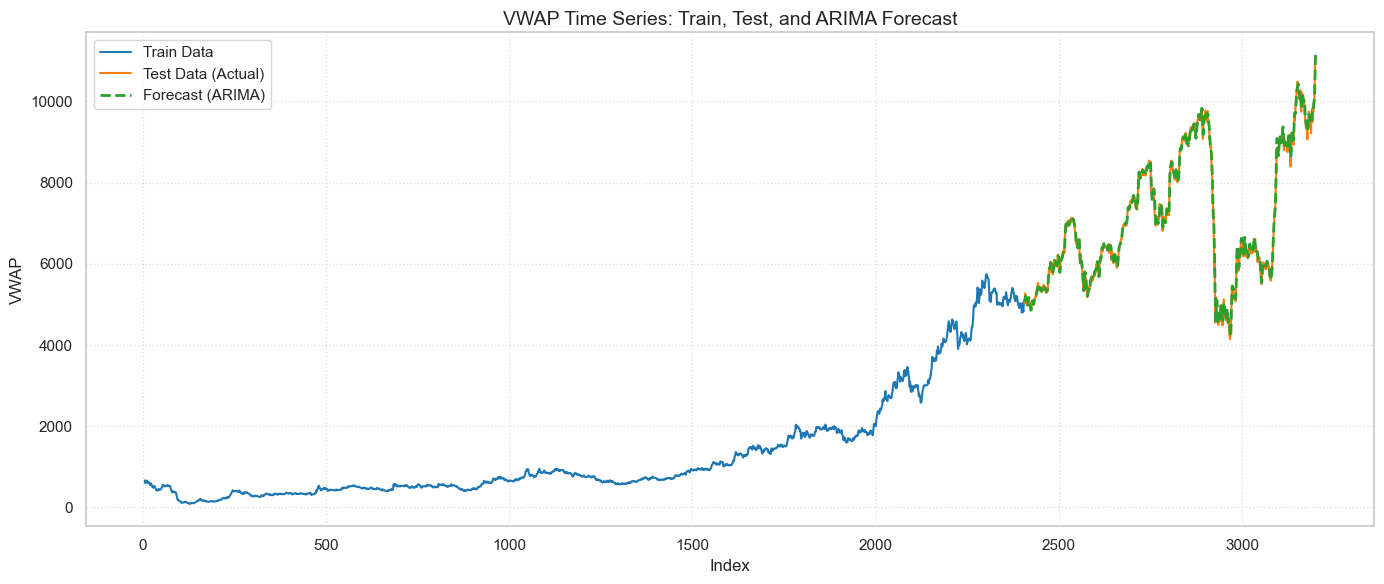

Metric,Value
Mean Absolute Error (MAE),76.3635
Mean Squared Error (MSE),"11,858.9810"
Root Mean Squared Error (RMSE),108.8989


In [52]:
import warnings
from warnings import filterwarnings
filterwarnings("ignore")

from sklearn.metrics import mean_absolute_error, mean_squared_error



# Generate Forecast
forecast = model.predict(n_periods=len(testing_data), X=testing_data[ind_features])

testing_data["Forecast_ARIMA"] = forecast.values

plt.figure(figsize=(14, 6))
plt.plot(
    training_data.index,
    training_data["VWAP"],
    label="Train Data",
    color="tab:blue",
    linewidth=1.5,
)
plt.plot(
    testing_data.index,
    testing_data["VWAP"],
    label="Test Data (Actual)",
    color="tab:orange",
    linewidth=1.5,
)
plt.plot(
    testing_data.index,
    testing_data["Forecast_ARIMA"],
    label="Forecast (ARIMA)",
    color="tab:green",
    linestyle="--",
    linewidth=2,
)

plt.title("VWAP Time Series: Train, Test, and ARIMA Forecast", fontsize=14)
plt.xlabel("Index", fontsize=12)
plt.ylabel("VWAP", fontsize=12)
plt.legend(loc="upper left", fontsize=11)
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

# Calculate Metrics
mse = mean_squared_error(testing_data["VWAP"], testing_data["Forecast_ARIMA"])
rmse = np.sqrt(mse)
mae = mean_absolute_error(testing_data["VWAP"], testing_data["Forecast_ARIMA"])

# Display Metrics neatly in a styled DataFrame
metrics_df = pd.DataFrame(
    {
        "Metric": [
            "Mean Absolute Error (MAE)",
            "Mean Squared Error (MSE)",
            "Root Mean Squared Error (RMSE)",
        ],
        "Value": [mae, mse, rmse],
    }
)

metrics_df.style.format({"Value": "{:,.4f}"}).hide(axis="index")

In [53]:
import os
print(os.getcwd())

C:\Users\maorm
